# Markov Coalescent Basics

Denne notebook introducerer coalescent modellen, som bruges til at beskrive den genetiske historie af en population baglæns i tid.

Modellen danner grundlag for:

- Site Frequency Spectrum (SFS)
- fylogenetiske træer
- demografiske modeller

Jeg starter med en simpel model og udvider forståelsen derfra.

In [1]:
# Importer nødvendige pakker 
from phasic import (
    Graph, with_ipv, StateIndexer, PropertySet, Property, GraphCache,
    print_graph_cache_info, get_graph_cache_stats, set_log_level
)
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from vscodenb import set_vscode_theme
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')
from phasic.state_indexing import StateIndexer, Property


## Coalescent modellen

Coalescent-processen beskriver, hvordan lineages bagud i tid coalescere sammen, indtil en fælles forfader er tilbage.

Jeg repræsenterer en state som en vektor:

- Index: antal efterkommere (1-ton, 2-ton, ...)
- Værdi: antal lineages af den type

Eksempel (4 samples):
(4, 0, 0, 0) → 4 singletons

Transitions opstår, når to lineages coalescer.
Raten er proportional med antallet af mulige par.

Dette implementeres som en callback-funktion til `Graph`.

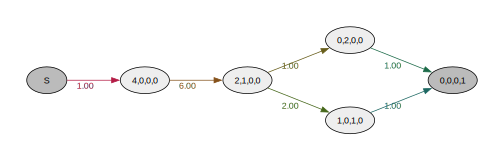

In [2]:
nr_samples = 4

@with_ipv([nr_samples] + [0]*(nr_samples-1))
def coalescent_model(state):
    transitions = []
    
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            
            rate = state[i] * (state[j] - same) / (1 + same)
            transitions.append([new, [rate]])
    
    return transitions

graph = Graph(coalescent_model)
graph.plot()

## Forventet coalescent tid

Expectation() giver den forventede tid indtil alle lineages har coalesceret.

Dette svarer til højden af et fylogenetisk træ.

In [3]:
print("Forventning:", graph.expectation())
print("Varians:", graph.variance())

Forventning: 1.4999999999999996
Varians: 1.1388888888888893


## Fordelinger (PDF og CDF)
Man kan også beregne hele fordelingen:

- PDF: tæthedsfunktion, beskriver sandsynligheden for coalescent tid. 
- CDF: fordelingsfunktion, beskriver sandsynligheden for at MRCA er nået før tid $t$.

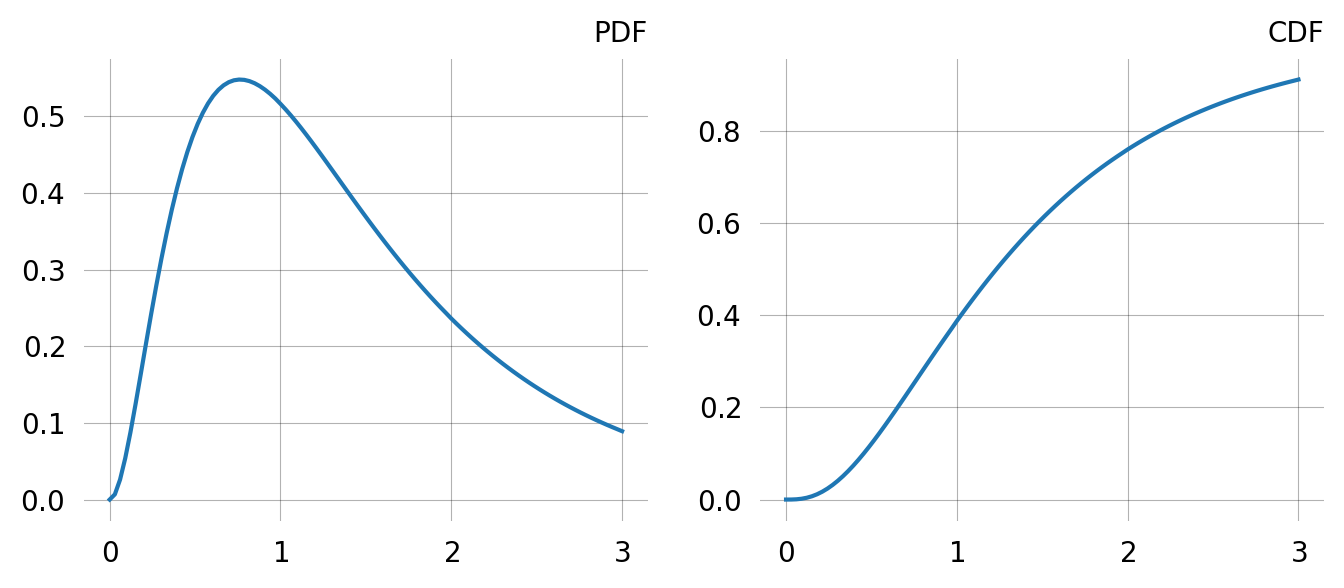

In [4]:
vals = np.linspace(0, 3, 100)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(vals, graph.pdf(vals))
axes[0].set_title("PDF")

axes[1].plot(vals, graph.cdf(vals))
axes[1].set_title("CDF")

plt.show()

## Simulation 

Man kan simulere samples fra modellen og sammenligne med teorien

In [5]:
samples = graph.sample(10000)
samples[:10]
print("Sample mean:", np.mean(samples).item())
print("Teoretisk mean:", graph.expectation())

Sample mean: 1.5050154860025744
Teoretisk mean: 1.4999999999999996


0.8041666666666667


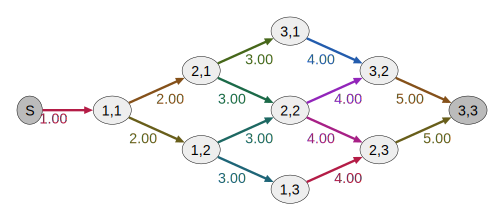

In [6]:
def mesh(state, max_val=None):
    transitions = []
    for i in range(state.size):
        if state[i] <= max_val:
            child = state.copy()
            child[i] += 1
            trans = [child, state.sum()]
            transitions.append(trans)
    return transitions

graph = Graph(mesh, ipv=[1, 1], max_val=2)
print(graph.expectation())
graph.plot(size=(7,5), fontsize=30, nodesep=1.5,ranksep=1.5, penwidth=5)

### Subgraphs 

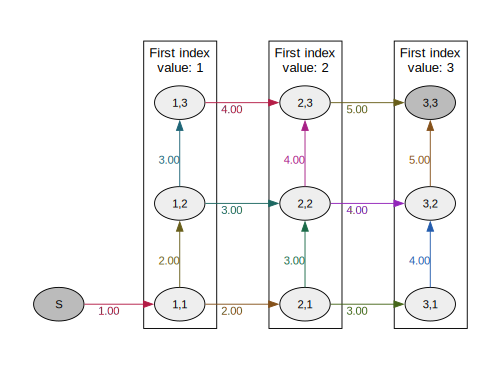

In [7]:
def fun(state):
    return f'First index\nvalue: {state[0]}'

graph.plot(by_state=fun)

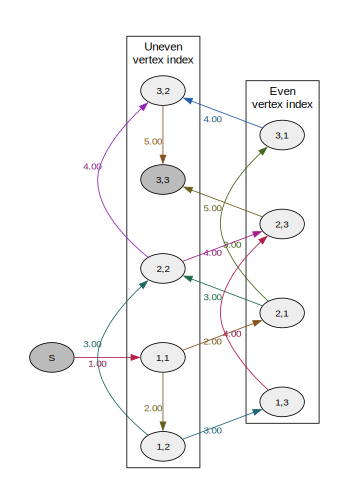

In [8]:
def fun(index):
    return f"{'Uneven' if index % 2 else 'Even'}\nvertex index"

graph.plot(by_index=fun)

## State space construction 

In [9]:
def coalescent(nr_samples):

    # we represent the state as a vector of integers, the numbers of lineages 
    # with "index" number of descendants
    state_vector_length = nr_samples

    # make an empty graph specifying the length of its state vectors
    graph = Graph(state_vector_length)

    # create the initial state where all samples are singletons
    initial_state = np.zeros(state_vector_length, dtype=int)
    initial_state[0] = nr_samples

    # find the initial state or create it if it does not exist yet
    vertex = graph.find_or_create_vertex(initial_state)

    # add an edge from the starting vertex to the initial state
    # signifying that the Markov chain starts in that state with 
    # probability 1
    graph.starting_vertex().add_edge(vertex, 1)

    # Graph index of the current vertex to process: The starting 
    # vertex is at index 0, so the initial_state is at index 1
    index = 1

    # For each vertex visited, we may create new child vertices not
    # yet visited. The while loop makes sure we continue processing
    # states until we have visited the ones we have created:
    while index < graph.vertices_length():

        # get the vertex at the current index
        vertex = graph.vertex_at(index)
        # get the state vector of that vertex
        state = vertex.state()

        # iterate over all combinations of the kinds of lineages
        # (singleton, doubleton, etc):
        for i in range(nr_samples):
            for j in range(i, nr_samples): 

                # if the two kinds are the same, there need to be at
                # least two lineages of that kind to coalesce
                same = int(i == j)
                if same and state[i] < 2:
                    continue

                # otherwise, at least one of each kind
                if not same and (state[i] < 1 or state[j] < 1):
                    continue 

                # create the new state vector to represent the child
                # state produced by the coalescence event
                new_state = state.copy()
                new_state[i] -= 1
                new_state[j] -= 1
                new_state[i+j+1] += 1
                
                # find the vertex with this state if it exists or 
                # create it otherwise
                new_vertex = graph.find_or_create_vertex(new_state)

                # compute the coalescent rate
                rate = state[i]*(state[j]-same)/(1+same)

                # add an edge from the current vertex to the new 
                # vertex and make its weight the coalescent rate
                vertex.add_edge(new_vertex, rate)

        # increment the index to process the next graph vertex
        index += 1
    
    return graph

In [10]:
graph = coalescent(4)
graph.vertices_length()

6

In [11]:
graph.states()

array([[0, 0, 0, 0],
       [4, 0, 0, 0],
       [2, 1, 0, 0],
       [0, 2, 0, 0],
       [1, 0, 1, 0],
       [0, 0, 0, 1]], dtype=int32)

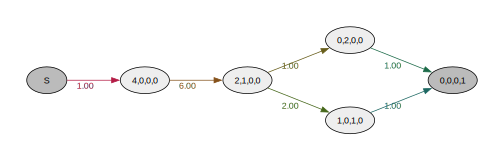

In [12]:
graph.plot()

## Matrix interface

In [13]:
mats = graph.as_matrices()
print("Initial probability vector:")
print(mats.ipv)
print("Subintensity matrix:")
print(mats.sim)
print("States:")
print(mats.states)
print("Indicies:")
print(mats.indices)

Initial probability vector:
[1. 0. 0. 0.]
Subintensity matrix:
[[-6.  6.  0.  0.]
 [ 0. -3.  1.  2.]
 [ 0.  0. -1.  0.]
 [ 0.  0.  0. -1.]]
States:
[[4 0 0 0]
 [2 1 0 0]
 [0 2 0 0]
 [1 0 1 0]]
Indicies:
[2 3 4 5]


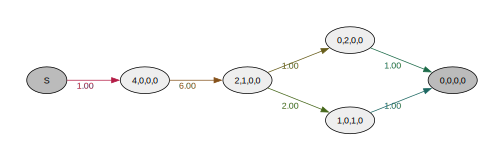

In [14]:
graph = Graph.from_matrices(mats.ipv, mats.sim, mats.states)
graph.plot()

## State properties and indexing


### Simple property

In [15]:
# Simple property: number of descendants (0 to 10)
descendants = Property('descendants', max_value=10)

print(f"Property: {descendants.name}")
print(f"Valid range: [{descendants.min_value}, {descendants.max_value}]")
print(f"Number of possible values: {descendants.base}")
print(f"Valid values: {list(descendants)}")

Property: descendants
Valid range: [0, 10]
Number of possible values: 11
Valid values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [16]:
population = Property('population', max_value=3, min_value=1)

print(f"Valid range: [{population.min_value}, {population.max_value}]")
print(f"Valid values: {list(population)}")

Valid range: [1, 3]
Valid values: [1, 2, 3]


In [17]:
# Create indexer with single property
indexer = StateIndexer(
    lineage=[Property('descendants', max_value=10)]
)

print(f"Total states: {indexer.state_length}")
print(f"PropertySet: {indexer.lineage}")

Total states: 11
PropertySet: PropertySet('lineage', state_length=11, properties=1)


### Conversion between index and properties

In [18]:
# Index to properties (returns dataclass by default)
props = indexer.lineage.i2p(5)
print(f"Index 5: {props}")
print(f"Access via attribute: props.descendants = {props.descendants}")

# Can also get as dict
props_dict = indexer.lineage.i2p(5, as_dict=True)
print(f"As dict: {props_dict}")

# Properties to index
idx = indexer.lineage.p2i({'descendants': 5})
print(f"{{descendants: 5}}: index {idx}")

# Also accepts dataclass
idx = indexer.lineage.p2i(props)
print(f"Dataclass: index {idx}")

Index 5: LineageProps(descendants=5)
Access via attribute: props.descendants = 5
As dict: {'descendants': 5}
{descendants: 5}: index 5
Dataclass: index 5


### Multiple properties

In [19]:
# Two properties: derived allele status (0 or 1) × descendants (0 to 4)
indexer2 = StateIndexer(
    lineage=[
        Property('derived', max_value=1),      # 2 values: 0, 1
        Property('descendants', max_value=4)   # 5 values: 0, 1, 2, 3, 4
    ]
)

print(f"Total states: {indexer2.state_length} (2 × 5 = 10)")
print(f"\nAll states:")
for i in indexer2.lineage:
    props = indexer2.lineage.i2p(i)
    print(f"  Index {i:2d}: derived={props.derived}, descendants={props.descendants}")

Total states: 10 (2 × 5 = 10)

All states:
  Index  0: derived=0, descendants=0
  Index  1: derived=1, descendants=0
  Index  2: derived=0, descendants=1
  Index  3: derived=1, descendants=1
  Index  4: derived=0, descendants=2
  Index  5: derived=1, descendants=2
  Index  6: derived=0, descendants=3
  Index  7: derived=1, descendants=3
  Index  8: derived=0, descendants=4
  Index  9: derived=1, descendants=4


### Slots for simple metadata storage

In [20]:
indexer3 = StateIndexer(
    'epoch', 'frequency',  # Positional slots
    lineage=[Property('descendants', max_value=10)]
)

print(f"PropertySet indices: 0-{indexer3.lineage.state_length-1}")
print(f"Slot 'epoch': index {indexer3.epoch}")
print(f"Slot 'frequency': index {indexer3.frequency}")
print(f"Total indices: {indexer3.state_length}")

PropertySet indices: 0-10
Slot 'epoch': index 11
Slot 'frequency': index 12
Total indices: 13


In [21]:
print("Index allocation:")
for name, (start, end) in indexer3.index_ranges.items():
    if start == end:
        print(f"  {name:12s}: index {start} (slot)")
    else:
        print(f"  {name:12s}: indices {start}-{end}")

Index allocation:
  lineage     : indices 0-11
  epoch       : index 11 (slot)
  frequency   : index 12 (slot)


### Slots with index_to_props

In [22]:
# Check what index 11 (epoch slot) maps to
result = indexer3.i2p(11)
print(f"Index 11:")
print(f"  lineage: {result.lineage}")
print(f"  epoch: {result.epoch}")
print(f"  frequency: {result.frequency}")

# Check a lineage index
result = indexer3.i2p(5)
print(f"\nIndex 5:")
print(f"  lineage: {result.lineage}")
print(f"  epoch: {result.epoch}")

Index 11:
  lineage: None
  epoch: True
  frequency: None

Index 5:
  lineage: LineageProps(descendants=5)
  epoch: None


### Multiple PropertySets

In [23]:
# Separate lineage properties from metadata
indexer4 = StateIndexer(
    'epoch', 'frequency',  # Slots
    lineage=[
        Property('derived', max_value=1),
        Property('descendants', max_value=4)
    ],
    metadata=[
        Property('time_bin', max_value=100)
    ]
)

print(f"lineage PropertySet: {indexer4.lineage.state_length} states")
print(f"metadata PropertySet: {indexer4.metadata.state_length} states")
print(f"Total indices: {indexer4.state_length}")
print(f"\nIndex allocation:")
for name, (start, end) in indexer4.index_ranges.items():
    if start == end:
        print(f"  {name:12s}: {start} (slot)")
    else:
        print(f"  {name:12s}: {start}-{end} ({end-start+1} states)")



lineage PropertySet: 10 states
metadata PropertySet: 101 states
Total indices: 113

Index allocation:
  lineage     : 0-10 (11 states)
  metadata    : 10-111 (102 states)
  epoch       : 111 (slot)
  frequency   : 112 (slot)


In [24]:
print("Lineage states:")
for i in list(indexer4.lineage)[:5]:  # First 5
    props = indexer4.lineage.i2p(i)
    print(f"  {i}: {props}")

print("\nMetadata states (first 3):")
for i in list(indexer4.metadata)[:3]:
    props = indexer4.metadata.i2p(i)
    print(f"  {i}: {props}")

Lineage states:
  0: LineageProps(derived=0, descendants=0)
  1: LineageProps(derived=1, descendants=0)
  2: LineageProps(derived=0, descendants=1)
  3: LineageProps(derived=1, descendants=1)
  4: LineageProps(derived=0, descendants=2)

Metadata states (first 3):
  0: MetadataProps(time_bin=0)
  1: MetadataProps(time_bin=1)
  2: MetadataProps(time_bin=2)


### Flatten mode

In [25]:
# Without flatten (default)
result = indexer4.i2p(5)
print(f"Without flatten: {result}")
print(f"  Access: result.lineage.derived = {result.lineage.derived}")

# With flatten=True
props = indexer4.i2p(5, flatten=True)
print(f"\nWith flatten=True: {props}")
print(f"  Direct access: props.derived = {props.derived}")

Without flatten: IndexResult(lineage=LineageProps(derived=1, descendants=2), metadata=None, epoch=None, frequency=None)
  Access: result.lineage.derived = 1

With flatten=True: LineageProps(derived=1, descendants=2)
  Direct access: props.derived = 1


In [26]:
# Common pattern: roundtrip within a PropertySet
print("Roundtrip demonstration:")
for i in list(indexer4.lineage)[:5]:
    props = indexer4.i2p(i, flatten=True)     # Get properties
    idx_back = indexer4.p2i(props)            # Convert back (auto-detects PropertySet!)
    print(f"  {i} -> {props} → {idx_back} ->")

Roundtrip demonstration:
  0 -> LineageProps(derived=0, descendants=0) → 0 ->
  1 -> LineageProps(derived=1, descendants=0) → 1 ->
  2 -> LineageProps(derived=0, descendants=1) → 2 ->
  3 -> LineageProps(derived=1, descendants=1) → 3 ->
  4 -> LineageProps(derived=0, descendants=2) → 4 ->


### Auto-detection Magic

In [27]:
# Properties are unique: 'derived', 'descendants' only in lineage; 'time_bin' only in metadata
indexer5 = StateIndexer(
    lineage=[
        Property('derived', max_value=1),
        Property('descendants', max_value=4)
    ],
    metadata=[
        Property('time_bin', max_value=100)
    ]
)

# Auto-detection works:
idx = indexer5.p2i({'derived': 1, 'descendants': 2})
print(f"Auto-detected 'lineage': {idx}")

idx = indexer5.p2i({'time_bin': 50})
print(f"Auto-detected 'metadata': {idx}")

# Also works with kwargs
idx = indexer5.p2i(derived=1, descendants=2)
print(f"Kwargs also work: {idx}")

Auto-detected 'lineage': 5
Auto-detected 'metadata': 60
Kwargs also work: 5


### Advanced Features

In [28]:
indexer6 = StateIndexer(
    lineage=[
        Property('derived', max_value=1),
        Property('descendants', max_value=4)
    ]
)

# Find all states with derived=1 (any number of descendants)
indices = indexer6.lineage.p2i({'derived': 1})
print(f"All states with derived=1: {indices}")
print("Properties:")
for i in indices:
    print(f"  {i}: {indexer6.lineage.i2p(i)}")

All states with derived=1: [1 3 5 7 9]
Properties:
  1: LineageProps(derived=1, descendants=0)
  3: LineageProps(derived=1, descendants=1)
  5: LineageProps(derived=1, descendants=2)
  7: LineageProps(derived=1, descendants=3)
  9: LineageProps(derived=1, descendants=4)


In [29]:
# Find all states with descendants=3
indices = indexer6.lineage.p2i({'descendants': 3})
print(f"\nAll states with descendants=3: {indices}")
print("Properties:")
for i in indices:
    print(f"  {i}: {indexer6.lineage.i2p(i)}")


All states with descendants=3: [6 7]
Properties:
  6: LineageProps(derived=0, descendants=3)
  7: LineageProps(derived=1, descendants=3)


## Two-locus ARG:

index	locus1	locus2
0	0	0
1	1	0
2	2	0
3	3	0
4	4	0
5	0	1
6	1	1
7	2	1
8	3	1
9	4	1
10	0	2
11	1	2
12	2	2
13	3	2
14	4	2
15	0	3
16	1	3
17	2	3
18	3	3
19	4	3
20	0	4
21	1	4
22	2	4
23	3	4
24	4	4


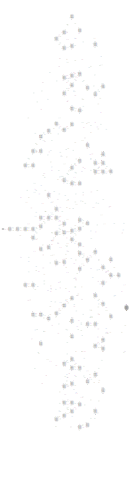

In [30]:
nr_samples = 4
indexer = StateIndexer(
    n_descendants=[
        Property('locus1', max_value=nr_samples),
        Property('locus2', max_value=nr_samples)
    ]
)

# zero state vector with appropriate size
initial = [0] * indexer.state_length

# set initial state with all lineages having one descendant at both loci
initial[indexer.props_to_index(locus1=1, locus2=1)] = nr_samples

@with_ipv(initial)
def two_locus_arg(state, indexer=None, N=None, R=None):

    transitions = []
    if state.sum() <= 1: return transitions

    for i in range(indexer.state_length):
        if state[i] == 0: continue
        props_i = indexer.n_descendants.index_to_props(i)

        for j in range(i, indexer.state_length):
            if state[j] == 0: continue
            props_j = indexer.n_descendants.index_to_props(j)
            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            locus1 = props_i.locus1 + props_j.locus1
            locus2 = props_i.locus2 + props_j.locus2
            if locus1 <= nr_samples and locus2 <= nr_samples:
                child[indexer.props_to_index(locus1=locus1, locus2=locus2)] += 1
                transitions.append([child, state[i]*(state[j]-same)/(1+same)/N])

        if state[i] > 0 and props_i.locus1 > 0 and props_i.locus2 > 0:
            child = state.copy()
            child[i] -= 1
            child[indexer.props_to_index(locus1=props_i.locus1, locus2=0)] += 1
            child[indexer.props_to_index(locus1=0, locus2=props_i.locus2)] += 1
            transitions.append([child, R])

    return transitions

print('index', 'locus1', 'locus2', sep='\t')
for i in indexer.n_descendants: 
    props = indexer.n_descendants.index_to_props(i) 
    print(i, props.locus1, props.locus2, sep='\t')

graph = Graph(two_locus_arg, 
                     N=1, R=1,
                     indexer=indexer) # passing indexer as argument
graph.plot(max_nodes=200)

In [31]:
graph.expectation()

2.0091445466464206

In [32]:
reward_matrix = graph.states().T

In [33]:
idx_singleton_loc1 = indexer.n_descendants.props_to_index(locus1=1)
idx_singleton_loc1

array([ 1,  6, 11, 16, 21])

In [34]:
reward_matrix = graph.states().T

singleton_rewards_loc1 = reward_matrix[idx_singleton_loc1].sum(axis=0)
singleton_rewards_loc1

array([0, 4, 2, 4, 0, 1, 2, 2, 2, 4, 4, 0, 0, 1, 1, 0, 1, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 4, 4, 4, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 0, 1, 2, 2, 4, 4, 4, 4, 4, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 0,
       1, 1, 2, 4, 4, 4, 4, 0, 0, 0, 1, 1, 2, 2, 0, 0, 1, 4, 4, 4, 0, 4])

In [35]:
graph.expectation(singleton_rewards_loc1)

1.9999999999999998

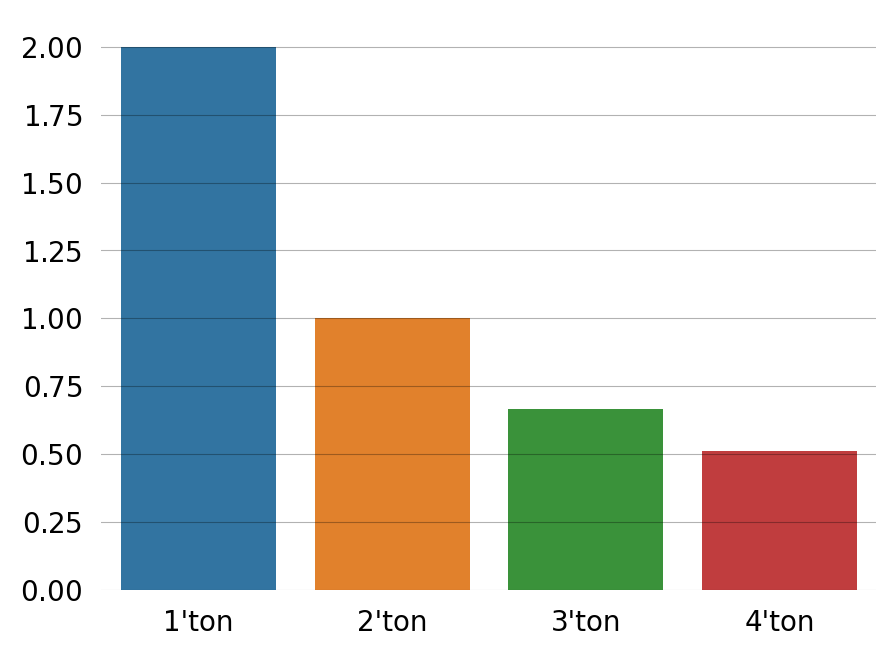

In [37]:
sfs_loc1 = [graph.expectation(reward_matrix[indexer.n_descendants.props_to_index(locus1=i)].sum(axis=0)) for i in range(1, nr_samples+1)]
labels = [f"{i+1}'ton" for i in range(nr_samples)]
sns.barplot(x=labels, y=sfs_loc1, hue=labels) ; 

## Moments and distributions

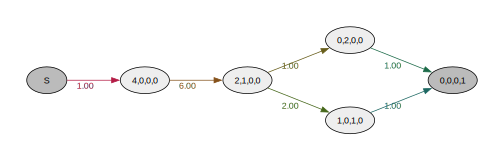

In [38]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, state[i]*(state[j]-same)/(1+same)))
    return transitions

graph = Graph(coalescent)
graph.plot()

In [39]:
labels = [f"{i+1}'ton" for i in range(nr_samples)]

pd.DataFrame(graph.states(), columns=labels)

,1'ton,2'ton,3'ton,4'ton
0,0,0,0,0
1,4,0,0,0
2,2,1,0,0
3,0,2,0,0
4,1,0,1,0
5,0,0,0,1


In [40]:
graph.expectation(),graph.variance()

(1.5, 1.1388888888888884)

In [41]:
graph.moments(3)

[1.5, 3.3888888888888884, 10.58333333333333]

In [42]:
graph.expected_waiting_time()

[1.5, 1.5, 1.3333333333333333, 1.0, 1.0, 0.0]

In [43]:
graph.expected_sojourn_time()

[0.0,
 0.16666666666666663,
 0.33333333333333326,
 0.3333333333333333,
 0.6666666666666666,
 0.0]

In [44]:
graph.accumulated_occupancy

<bound method Graph.accumulated_occupancy of <Graph (6 vertices)>>

### CDF and PDF

In [45]:
time = np.arange(0, 4, 0.001)
cdf = graph.cdf(time)
pdf=graph.pdf(time)

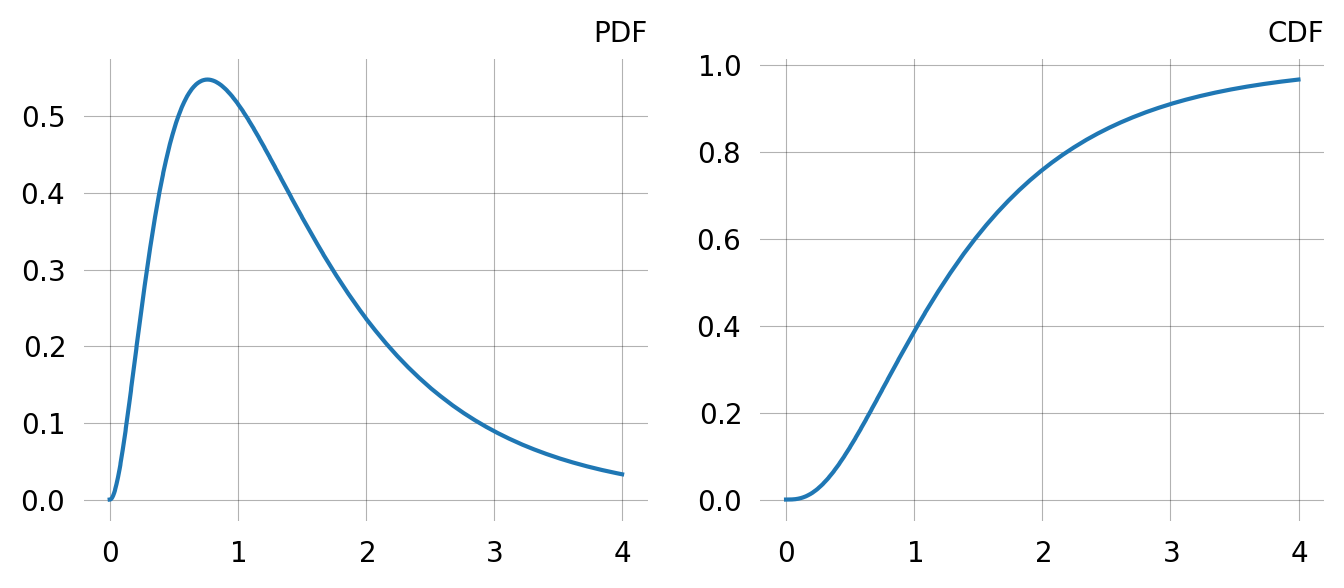

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.plot(time, graph.pdf(time))
ax1.set_title("PDF")
ax2.plot(time, graph.cdf(time))
ax2.set_title("CDF") ;

## Rewards

In [47]:
graph = Graph(coalescent)
reward_matrix = graph.states().T
doubletons = reward_matrix[1]
doubletons

array([0, 0, 1, 2, 0, 0], dtype=int32)

In [48]:
graph.expectation(doubletons), graph.variance(doubletons)

(0.9999999999999999, 2.333333333333333)

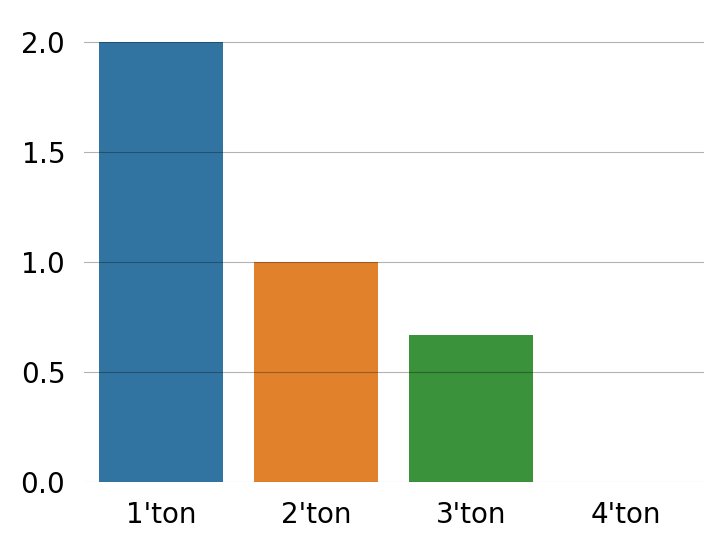

In [49]:
labels = [f"{i+1}'ton" for i in range(reward_matrix.shape[0])]
sfs = [graph.expectation(r) for r in reward_matrix]
plt.figure(figsize=(4, 3))
sns.barplot(x=labels, y=sfs, hue=labels) ;

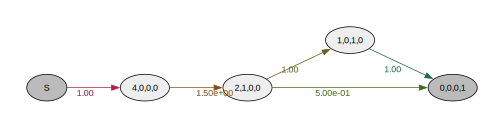

In [50]:
singleton_graph = graph.reward_transform(reward_matrix[0])
singleton_graph.plot()

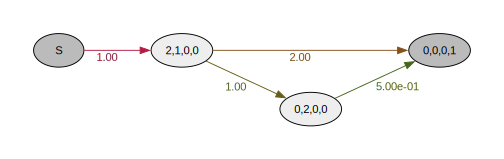

In [51]:
doubleton_graph = graph.reward_transform(reward_matrix[1])
doubleton_graph.plot()

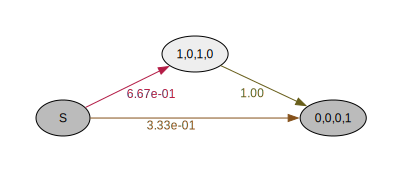

In [52]:
tripleton_graph = graph.reward_transform(reward_matrix[2])
tripleton_graph.plot()

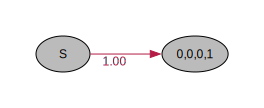

In [53]:
quadrupleton_graph = graph.reward_transform(reward_matrix[3])
quadrupleton_graph.plot()

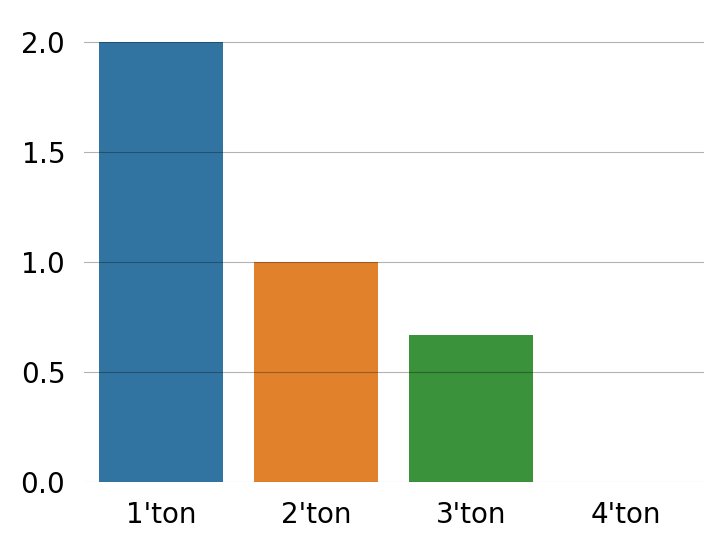

In [54]:
sfs = [
    singleton_graph.expectation(),
    doubleton_graph.expectation(),
    tripleton_graph.expectation(),
    quadrupleton_graph.expectation()
]
plt.figure(figsize=(4, 3))
sns.barplot(x=labels, y=sfs, hue=labels) ;

In [55]:
graph = Graph(coalescent)
singleton_rewards = graph.states().T[0]

In [56]:
%%timeit
graph.expectation(singleton_rewards)

9.97 μs ± 262 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [57]:
%%timeit
graph.reward_transform(singleton_rewards).expectation()

31.1 μs ± 2.06 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


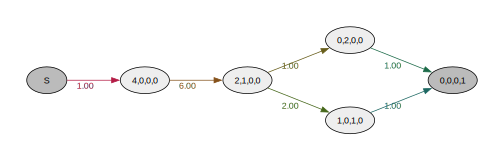

In [58]:
graph = Graph(coalescent)
graph.plot()

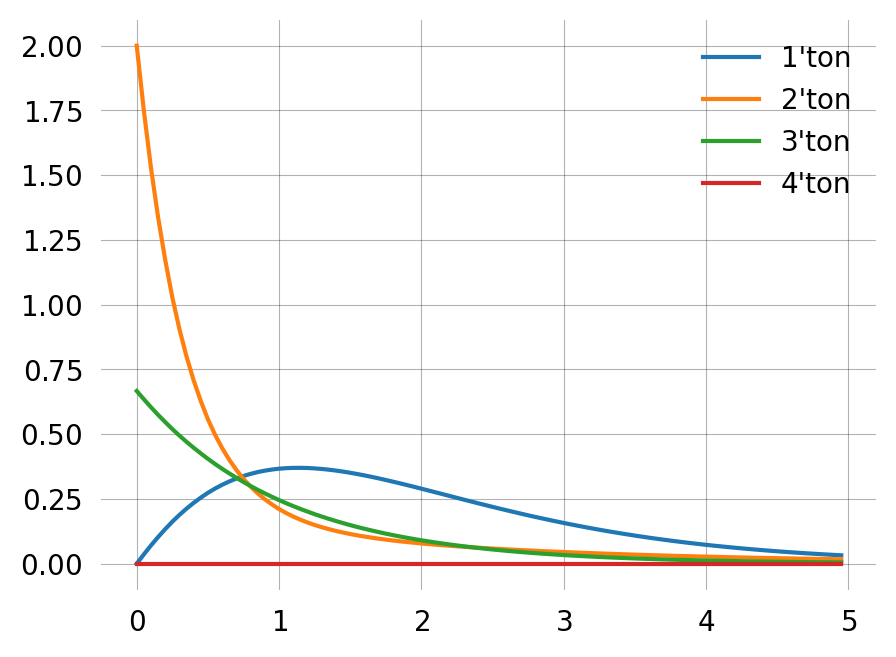

In [59]:
times = np.arange(0, 5, 0.05)
reward_matrix = graph.states().T
labels = [f"{i+1}'ton" for i in range(reward_matrix.shape[1])]

for i, rewards in enumerate(reward_matrix):
    revt_graph = graph.reward_transform(rewards)
    plt.plot(times, revt_graph.pdf(times), label=labels[i])
plt.legend() ;

## State probability and occupancy

In [60]:
graph = Graph(coalescent)
graph.state_probability(0.2)

[0.0,
 0.2997804995651261,
 0.49645277537763904,
 0.06299978987254216,
 0.12599957974508433,
 0.0]

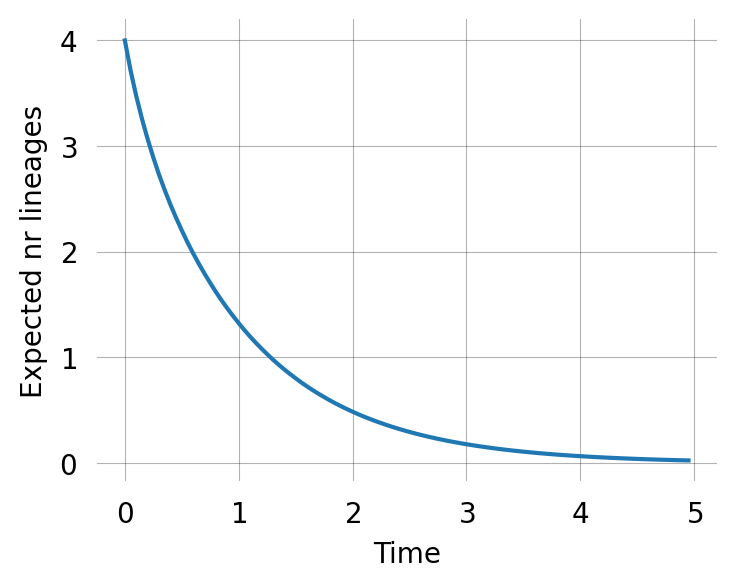

In [61]:
times = np.arange(0, 5, 0.05)
expected_lineages_left = [
    np.sum(graph.state_probability(i) 
           * np.sum(graph.states(), axis=1)) 
    for i in times
    ]

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.plot(times, expected_lineages_left)
ax.set_xlabel('Time')
ax.set_ylabel("Expected nr lineages") ;

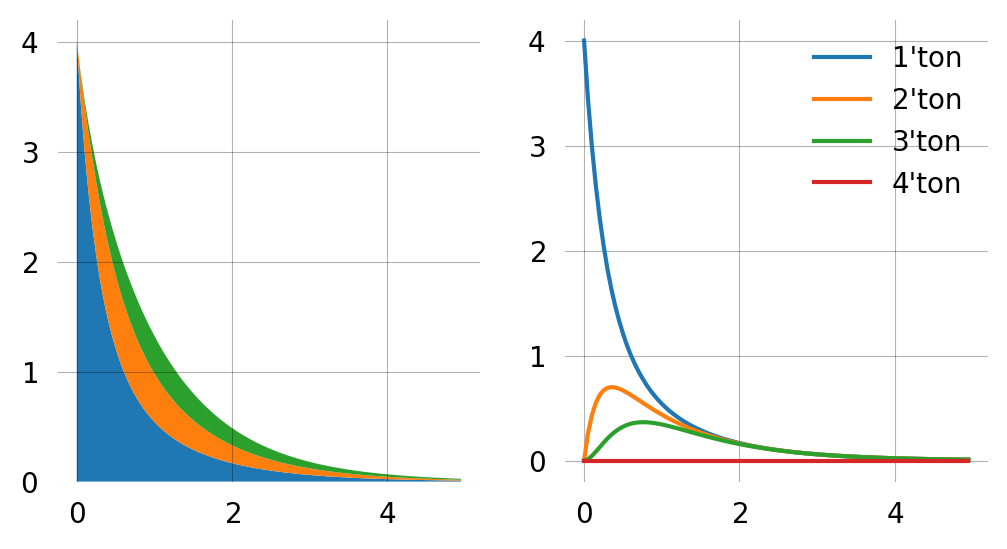

In [62]:
times = np.arange(0, 5, 0.05)
state_probs = np.array([graph.state_probability(i) * graph.states().T for i in times])
labels = [f"{i+1}'ton" for i in range(state_probs.shape[1])]
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].stackplot(times, np.sum(state_probs, axis=2).T)
axes[1].plot(times, np.sum(state_probs, axis=2), label=labels)
# plt.subplot(121).stackplot(times, np.sum(state_probs, axis=2).T)
# plt.subplot(122).plot(times, np.sum(state_probs, axis=2), label=labels)
plt.legend() ;

In [63]:
rewards = (graph.states()[:,1]>0).astype(int)
np.sum(graph.accumulated_occupancy(time=1.5) * rewards)

np.float64(0.5293813150697066)

## Discrete phase-type distributions

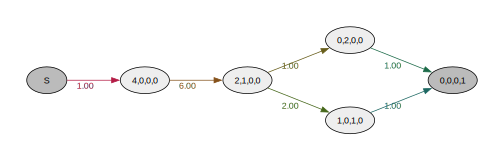

In [64]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, state[i]*(state[j]-same)/(1+same)))
    return transitions

mutation_graph = Graph(coalescent)
mutation_graph.plot()

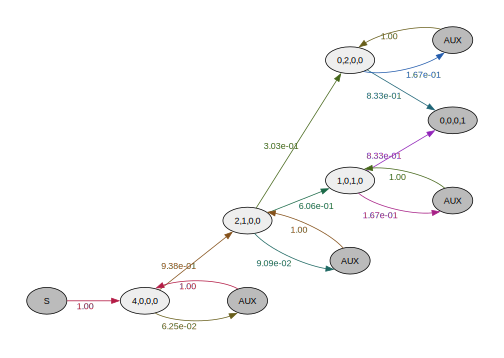

In [65]:
from typing import Optional

mutation_graph = Graph(coalescent)

def mutation(state:np.ndarray, mutation_rate:float):
    nr_lineages = sum(state)
    return nr_lineages * mutation_rate

mutation_rate = 0.1
rewards = mutation_graph.discretize(mutation, mutation_rate=mutation_rate)
mutation_graph.plot()

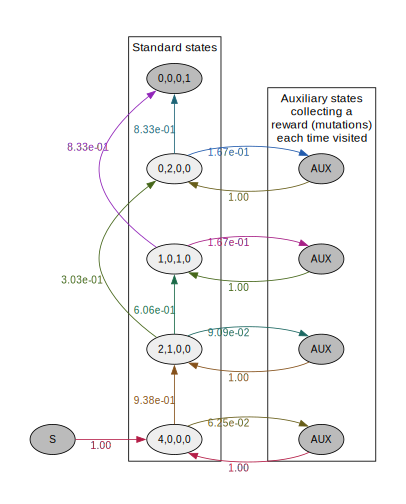

In [66]:
def fun(index):
    if rewards[index]:
        return "Auxiliary states\ncollecting a\nreward (mutations)\neach time visited"
    else:
        return "Standard states"

mutation_graph.plot(by_index=fun)

In [67]:
mutation_graph.expectation(rewards)

0.3666666666666667

In [68]:
graph = Graph(coalescent)
tot_brlen = graph.expectation(graph.states().T.sum(axis=0))
tot_brlen * mutation_rate

0.36666666666666664

In [69]:
samples = mutation_graph.sample(10000, rewards=rewards)
samples.mean().item()

0.3562

In [70]:
samples = graph.sample(10000, rewards=graph.states().T.sum(axis=0))
samples.mean().item() * mutation_rate

0.3647952390920026

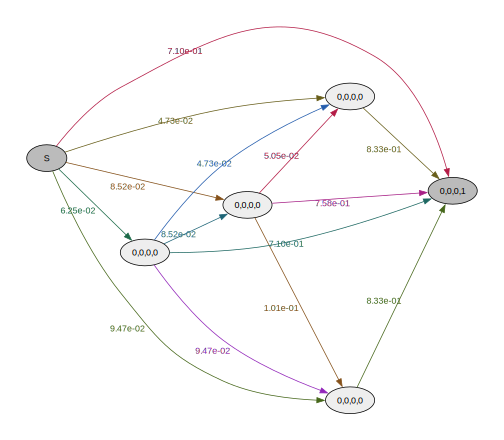

In [71]:
rev_trans_mutation_graph  = mutation_graph.reward_transform_discrete(rewards)
rev_trans_mutation_graph.plot()

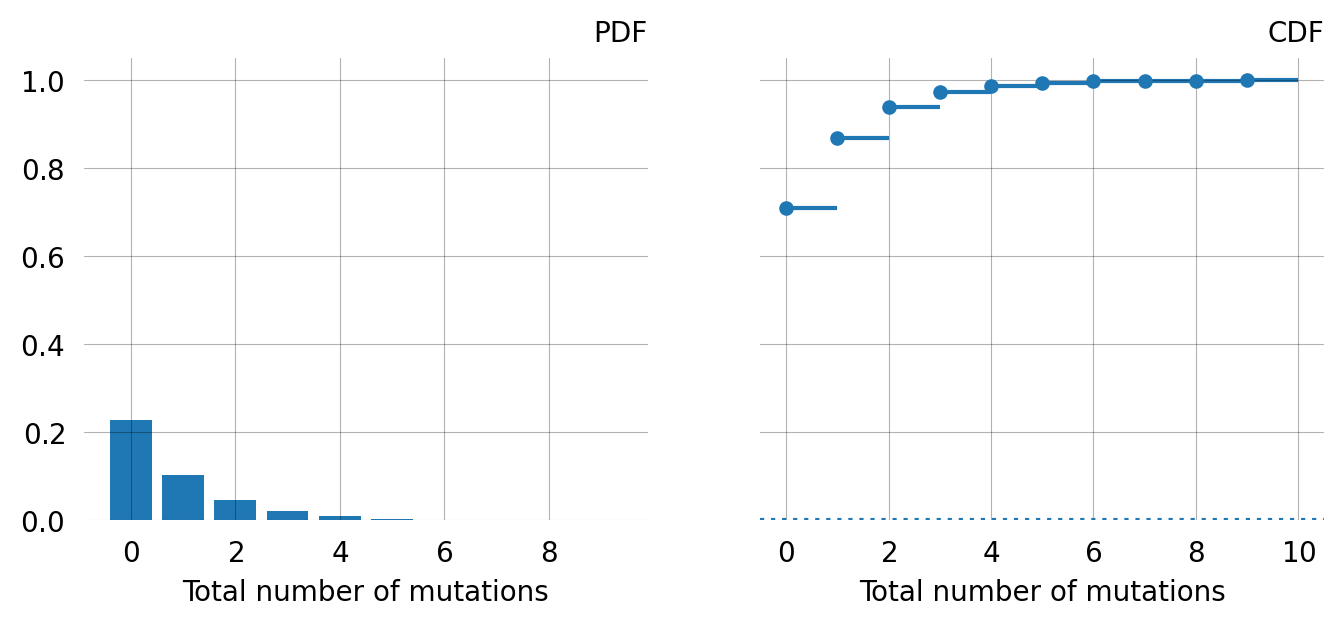

In [72]:
mutations = np.arange(10)
pmf = rev_trans_mutation_graph.pdf(mutations)
cdf = rev_trans_mutation_graph.cdf(mutations)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
x = np.arange(0, 10, 1)
ax1.bar(x, pmf)
ax1.set_title("PDF")
ax1.set_xlabel('Total number of mutations')
left, right = x, np.arange(1, x.size+1, 1)
ax2.hlines(y=cdf, xmin=left, xmax=right, zorder=1)
ax2.scatter(left, cdf, s=18, zorder=2)
ax2.set_title("CDF")
ax2.set_xlabel('Total number of mutations')
ax2.axhline(y=mutation_graph.defect(), linestyle='dotted') ;

## Multivariate phase-type distributions

singleton rewards are:

In [73]:
graph = Graph(coalescent)
reward_matrix = graph.states().T

singleton = reward_matrix[0]
doubleton = reward_matrix[1]
tripleton = reward_matrix[2]

print(f"Singleton rewards: {singleton}")

Singleton rewards: [0 4 2 0 1 0]


In [74]:
graph.expectation(singleton)

1.9999999999999996

In [75]:
graph.covariance(singleton, doubleton)

-0.2222222222222221

In [76]:
nsims = 1000000
samples = graph.sample_multivariate(nsims, graph.states())
samples.shape

(4, 1000000)

In [77]:
float(sum(samples[0,:]*samples[1,:])/nsims - sum(samples[0,:])/nsims*sum(samples[1,:])/nsims)

-0.22536485100966686

## Parameterized models

In [78]:
nr_samples = 4
indexer = StateIndexer(descendants=[
    Property('loc1', max_value=nr_samples),
    Property('loc2', max_value=nr_samples)
])

initial = [0] * indexer.state_length
initial[indexer.props_to_index(loc1=1, loc2=1)] = nr_samples

@with_ipv(initial)
def two_locus_arg_2param(state, indexer=None): # <- changed

    transitions = []
    if state.sum() <= 1: return transitions

    for i in range(indexer.state_length):
        if state[i] == 0: continue
        pi = indexer.index_to_props(i)

        for j in range(i, indexer.state_length):
            if state[j] == 0: continue
            pj = indexer.index_to_props(j)
            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            loc1 = pi.descendants.loc1 + pj.descendants.loc1
            loc2 = pi.descendants.loc2 + pj.descendants.loc2
            if loc1 <= nr_samples and loc2 <= nr_samples:
                child[indexer.props_to_index(loc1=loc1, loc2=loc2)] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]]) # <- changed

        if state[i] > 0 and pi.descendants.loc1 > 0 and pi.descendants.loc2 > 0:
            child = state.copy()
            child[i] -= 1
            child[indexer.props_to_index(loc1=pi.descendants.loc1, loc2=0)] += 1
            child[indexer.props_to_index(loc1=0, loc2=pi.descendants.loc2)] += 1
            transitions.append([child, [0, 1]])                                 # <- changed

    return transitions


graph = Graph(two_locus_arg_2param, indexer=indexer) 

Numbers of parameteres

In [79]:
graph.param_length()

2

In [80]:
graph.update_weights([1/3, 5])
graph.expectation()

8.738072538847756

In [81]:
graph.update_weights([1/3, 5], callback = lambda param, coef: np.sum(param * coef))
graph.expectation()

8.738072538847756

In [83]:
R_values = [1, 2, 1, 2, 1, 2]
N_values = [1, 1, 1.5, 1.5, 2, 2]

for N, R in zip(N_values, R_values):
    graph.update_weights([1/N, R])
    print(f'N:{N:<5} R:{R:<4} Mean: {graph.expectation():.4f}   Var:{graph.variance():.4f}')

N:1     R:1    Mean: 2.0090   Var:2.0643
N:1     R:2    Mean: 2.2947   Var:2.3297
N:1.5   R:1    Mean: 3.2562   Var:5.0346
N:1.5   R:2    Mean: 3.7030   Var:5.4037
N:2     R:1    Mean: 4.5894   Var:9.3188
N:2     R:2    Mean: 5.1653   Var:9.6597


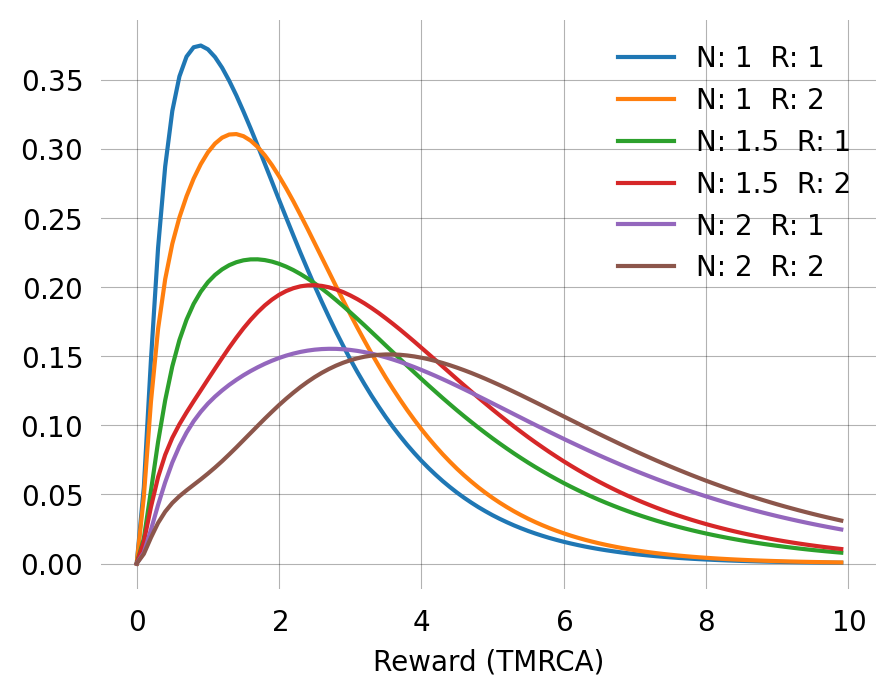

In [84]:
x = np.arange(0, 10, 0.1)
for N, R in zip(N_values, R_values):
    graph.update_weights([1/N, R])
    plt.plot(x, graph.pdf(x), label=f'N: {N}  R: {R}')
plt.xlabel('Reward (TMRCA)')
plt.legend()
plt.show()

## Discrete phase-type distributions

Discrete rewards (indices of AUX vertices): [0 0 0 0 0 0 1 1 1 1]


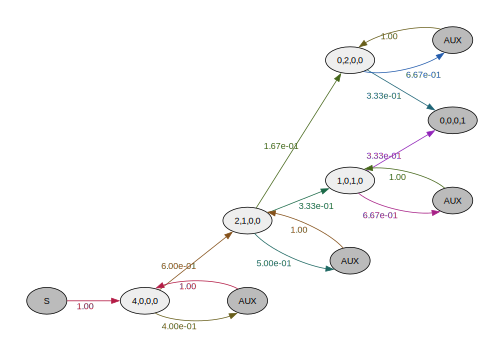

In [85]:
@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_2param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, [state[i]*(state[j]-same)/(1+same), 0]))
    return transitions

mutation_graph = Graph(coalescent_2param)

def mutation_rate(state):
    nr_lineages = sum(state)
    return [0, nr_lineages]

rewards = mutation_graph.discretize(mutation_rate)                               
                                    
print("Discrete rewards (indices of AUX vertices):", rewards)
mutation_graph.plot()

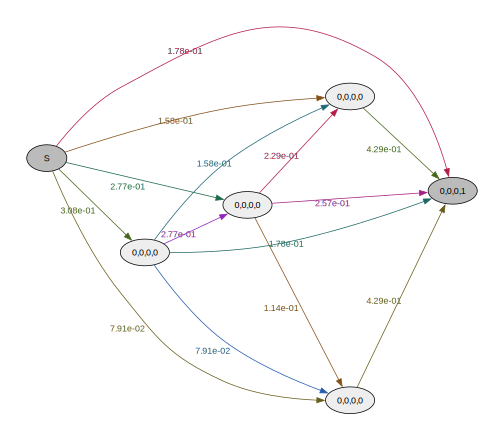

In [86]:
mutation_graph.update_weights([3, 2])
rt_graph = mutation_graph.reward_transform(rewards)
rt_graph.plot()

In [87]:
mutation_graph.update_weights([3, 2])
rt_graph = mutation_graph.reward_transform(rewards)
rt_graph.pdf(2)

0.14830307025146525

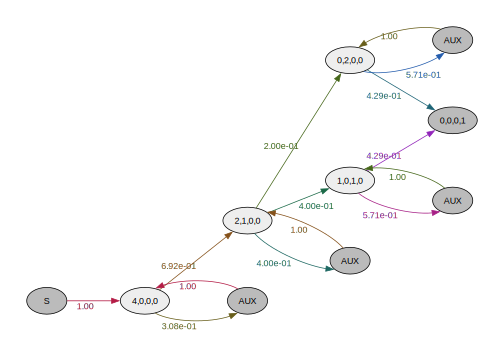

In [88]:
mutation_graph.plot()

In [89]:
rt_graph.expectation(), mutation_graph.expectation(rewards)

(2.4444444444444446, 2.444444444444444)

In [90]:
rt_graph.variance(), mutation_graph.variance(rewards)

(7.308641975308638, 4.864197530864198)

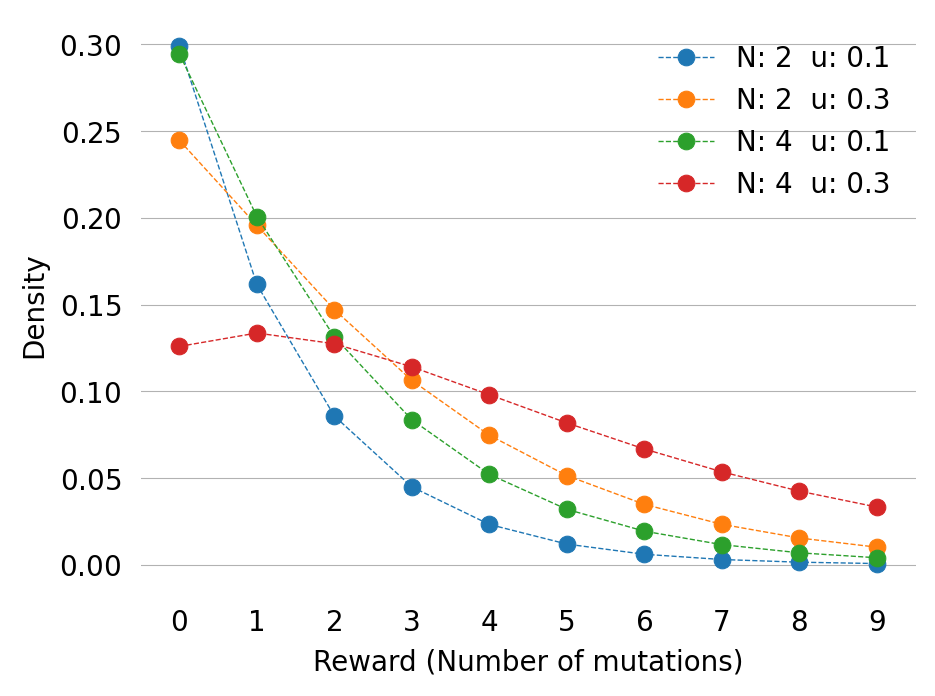

In [91]:
N_values = [2, 2, 4, 4, ]
u_values = [0.1, 0.3, 0.1, 0.3]
x = np.arange(0, 10, 1)
for N, u in zip(N_values, u_values):
    mutation_graph.update_weights([1/N, u])
    rt_graph = mutation_graph.reward_transform(rewards)
    sns.pointplot(x=x, y=rt_graph.pdf(x), label=f'N: {N}  u: {u}', 
                  linestyle='dashed', markers='o', 
                  markersize=6, linewidth=0.5)
plt.xlabel('Reward (Number of mutations)')
plt.ylabel('Density')
plt.legend()
plt.show()